<a href="https://colab.research.google.com/github/s-grzhang/necrophobia-filter/blob/master/Second_Try_Necrophobia_Filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
# Define paths to your dataset
train_dir = '/content/drive/MyDrive/Dataset/Test'
test_dir = '/content/drive/MyDrive/Dataset/Train'

# Define image size and batch size
IMAGE_SIZE = (300, 300)
BATCH_SIZE = 10

# Create ImageDataGenerator instances for training and testing data
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0, 1]
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    rescale=1./255  # Normalize pixel values to [0, 1]
)

# Load and preprocess the training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'  # Change to 'categorical' if you have more than 2 categories
)

# Load and preprocess the testing data
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'  # Change to 'categorical' if you have more than 2 categories
)


Found 102 images belonging to 2 classes.
Found 126 images belonging to 2 classes.


In [ ]:
model = Sequential([
    # First convolutional layer
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # Second convolutional layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Third convolutional layer
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flattening layer
    Flatten(),

    # Fully connected layer
    Dense(128, activation='relu'),
    Dropout(0.5),  # Dropout for regularization

    # Output layer
    Dense(1, activation='sigmoid')  # Use 'softmax' if you have more than 2 categories
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',  # Use 'categorical_crossentropy' if you have more than 2 categories
    metrics=['accuracy']
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=10,  # You can adjust the number of epochs based on your needs
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE
)


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 117s 9s/step - accuracy: 0.5389 - loss: 0.8969 - val_accuracy: 0.4167 - val_loss: 0.7621
Epoch 2/10
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7000 - loss: 0.6488

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 471ms/step - accuracy: 0.7000 - loss: 0.6488 - val_accuracy: 0.1667 - val_loss: 0.7724
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 373ms/step - accuracy: 0.4921 - loss: 0.7185 - val_accuracy: 0.5917 - val_loss: 0.6543
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5000 - loss: 0.6995 - val_accuracy: 0.6667 - val_loss: 0.6664
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 491ms/step - accuracy: 0.5466 - loss: 0.6661 - val_accuracy: 0.5000 - val_loss: 0.6613
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5000 - loss: 0.7303 - val_accuracy: 0.5000 - val_loss: 0.6771
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 431ms/step - accuracy: 0.5761 - loss: 0.6426 - val_accuracy: 0.6917 - val_loss: 0.5942
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6000 - loss: 0.5400 - val_accuracy: 1.0000 - val_loss: 0.4554
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 395ms/step - accuracy: 0.7033 - loss: 0.5954 - val_accuracy: 0.6083 - val_lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 243ms/step - accuracy: 0.5585 - loss: 0.6838
Test Loss: 0.6848403215408325
Test Accuracy: 0.5476190447807312


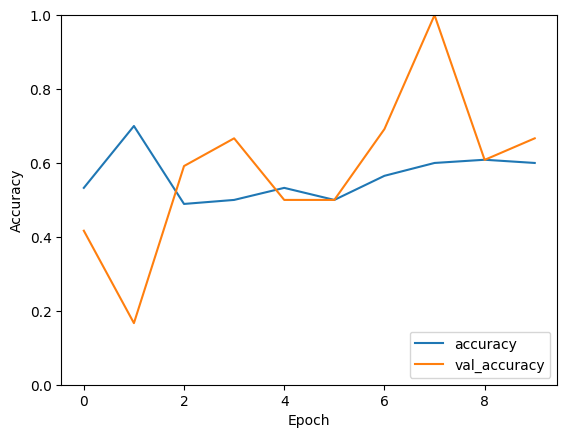

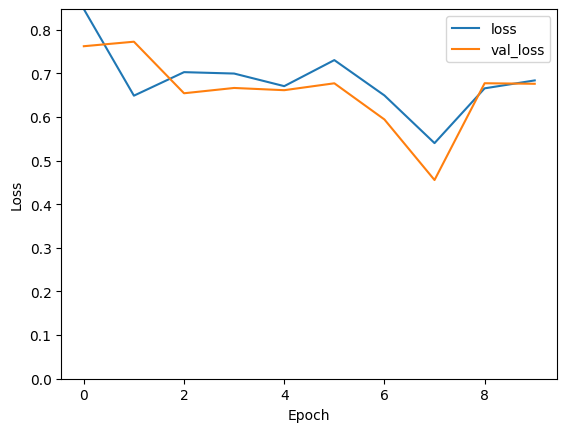

In [ ]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

# Optionally, you can plot the training and validation accuracy and loss
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, max(history.history['loss'])])
plt.legend(loc='upper right')
plt.show()

In [ ]:
#ok...she's underfitted...
# add more data
# more epochs